<a href="https://colab.research.google.com/github/prasa129/Math/blob/main/NN_Function_Space.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network Function Space

11-26-2025

## Background and Experimental Setup

Consider the vector space $U$ of all real polynomials of degree $ \le D$.  

$$
U = \left\{ f : \mathbb{R} \to \mathbb{R} \;\big|\;
f(x) = \sum_{k=0}^{D} a_k x^k, \; a_k \in \mathbb{R} \right\}
$$

This is a $(D+1)$-dimensional real vector space with monomial basis

$$
\mathcal{B} = \{1, x, x^2, \dots, x^D\}.
$$

The space is closed under addition and scalar multiplication. Let

$$
f(x) = \sum_{k=0}^D a_k x^k
$$  

and  

$$
g(x) = \sum_{k=0}^D b_k x^k
$$

then

$$
f(x) + g(x) = \sum_{k=0}^D (a_k + b_k) x^k \in V
$$

and for any scalar $\lambda \in \mathbb{R}$,

$$
\lambda f(x) = \sum_{k=0}^D (\lambda a_k) x^k \in V.
$$

Examples of functions in $V$ include

$$
f_1(x) = 3 - x + 2x^3, \qquad
f_2(x) = -1 + 5x^4, \qquad
f_3(x) = 0.2 + 0.7x + 0.1x^2.
$$

Each polynomial $f \in V$ is represented uniquely by its coefficient vector

$$
\beta = (a_0, a_1, \dots, a_D)^\top \in \mathbb{R}^{D+1}.
$$

When evaluated at $m$ sample points $x_1,\dots,x_m$, the values of $f$ form the vector

$$
y =
\begin{bmatrix}
f(x_1) \\ \vdots \\ f(x_m)
\end{bmatrix}.
$$

Let $V$ be a $m \times (D+1)$ Vandermonde matrix with entries $(V)_{ik} = x_i^k$, then $y= V \beta$

$$
\begin{bmatrix}
f(x_1) \\ f(x_2) \\ \vdots \\ f(x_m)
\end{bmatrix} = \begin{bmatrix}
1      & x_1      & x_1^2      & \cdots & x_1^{D} \\
1      & x_2      & x_2^2      & \cdots & x_2^{D} \\
\vdots & \vdots   & \vdots     & \ddots & \vdots  \\
1      & x_m      & x_m^2      & \cdots & x_m^{D}
\end{bmatrix} \begin{bmatrix}
a_0 \\ a_1 \\ \vdots \\ a_D
\end{bmatrix}.
$$

For distinct sample points $x_i$ and $m \ge D+1$, the mapping is injective. A sufficiently deep network can trivially memorize pairs of coefficient vectors and function values. I answer two questions:

1. Can a simple linear neural network learn, from data alone and without ever seeing $V$, to approximate the inverse map $y \mapsto \beta$?

2. Does the network’s hidden representation span the same function space as the monomials, and can it can recover the internal structure of $V$?

To do so, I perform the following experiment. First, I generate many random polynomials of varying degree $d \le D$, sample each polynomial at a fixed grid of $m$ points, and train a neural network on pairs $(y,\beta)$, where $y \in \mathbb{R}^m$ is the vector of sampled function values and $\beta \in \mathbb{R}^{D+1}$ is the padded coefficient vector. Second, I evaluate whether the network post-training has learned the exact inverse operator $y \mapsto \beta$ by regressing the learned basis on monomials. Finally, I examine how the network behaves adversarially when presented with polynomials whose degree exceeds $D$.

## Constructing Training Dataset

Training examples are generated as follows. For each sample:

1. Draw a random degree $d$ uniformly from $\{0,1,\dots,D\}$.

2. Draw coefficients $a_0,\dots,a_d$ independently from a Gaussian distribution (and pad with zeros for $k>d$).  

3. Form the coefficient vector

$$
\beta = (a_0,\dots,a_D)^\top \in \mathbb{R}^{D+1}.
$$

4. Compute function samples  

$$
y = V_{\text{sample}} \beta \in \mathbb{R}^m.
$$

Thus the training dataset consists of pairs

$$
(y_i, \beta_i) \in \mathbb{R}^m \times \mathbb{R}^{D+1},
\qquad i=1,\dots,N.
$$

The neural network receives the function-sample vector $y_i$ as input and is trained to output the corresponding coefficient vector $\beta_i$. I implement the polynomial map $y = V_{\text{sample}} \beta$ and the random polynomial generator. I defines the function space $V$, sample points $\{x_i\}$, and the Vandermonde matrix needed to evaluate polynomials on that grid.

In [1]:
# imports
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense

# set display precision
pd.set_option("display.float_format", "{:.4f}".format)


def build_vandermonde(x, degree_max):
    """
    Construct Vandermonde matrix for given x and max degree.
    Args:
    -----
        x (numpy.ndarray) : Shape (n_points,), x-values.
        degree_max (int)  : Maximum polynomial degree D.
    Returns:
    --------
        V (numpy.ndarray) : Shape (n_points, D+1), V[i,k] = x[i]^k.
    """

    # ensure 1D array
    x = np.asarray(x).ravel()

    # construct Vandermonde with increasing powers
    V = np.vander(x, N=degree_max+1, increasing=True)

    return V


def sample_random_polynomial(degree_max,
                             coef_scale=1.0,
                             random_state=None):
    """
    Draw a random polynomial of random degree d <= degree_max.
    Args:
    -----
        degree_max (int)   : Maximum allowed degree D.
        coef_scale (float) : Std dev of coefficients.
        random_state (int) : RNG seed.
    Returns:
    --------
        d (int)                : Actual degree drawn (0,...,D).
        beta_full (np.ndarray) : Coeffs of length D+1 (padded with zeros).
    """

    # RNG
    rng = np.random.default_rng(random_state)

    # draw degree uniformly from {0,...,D}
    d = rng.integers(low=0, high=degree_max+1)

    # draw coefficients up to degree d
    beta = rng.normal(loc=0.0, scale=coef_scale, size=d+1)

    # pad with zeros up to D+1
    beta_full = np.zeros(degree_max+1)
    beta_full[: d+1] = beta

    return d, beta_full

# set maximum degree
degree_max = 5

# choose number of sample points (>= degree_max+1 for identifiability)
n_sample = degree_max + 2

# x locations where we observe the function
x_sample = np.linspace(-1.0, 1.0, n_sample)

# Vandermonde on sample grid
V_sample = build_vandermonde(x_sample, degree_max)

print("\n=== Training Data Parameters ===")
print("Max degree D       :", degree_max)
print("Sample grid size   :", n_sample)
print("V_sample shape     :", V_sample.shape)



=== Training Data Parameters ===
Max degree D       : 5
Sample grid size   : 7
V_sample shape     : (7, 6)


Next I construct the dataset of input/output pairs $\{(y_i,\beta_i)\}_{i=1}^{N}$. For each training polynomial, I sample a random degree $d \le D$ and a corresponding padded coefficient vector $\beta_{\text{full}} \in \mathbb{R}^{D+1}$. I then compute the function values on the sample grid via

$$
y_{\text{sample}} = V_{\text{sample}} \beta_{\text{full}},
$$

optionally adding noise. The array $\texttt{Y_sample_train}$ stores the inputs $y_{\text{sample}}$ of shape $(N,\texttt{n_sample})$, and $\texttt{B_train}$ stores the outputs $\beta_{\text{full}}$ of shape $(N,D+1)$.

Given only function samples $y_{\text{sample}}$, the network has to infer the underlying coefficient vector $\beta$ for polynomials of varying degree without any exposure to $V_{\text{sample}}$, monomials, or polynomial degrees. The data covers the full subspace of polynomials of degree $\le D$, so the network has enough information to identify the inverse operator on that subspace.

In [2]:
def generate_dataset(V_sample,
                     n_polynomials=3000,
                     coef_scale=1.0,
                     noise_std=0.0,
                     random_state=1776):
    """
    Generate training data mapping function samples to polynomial coefficients.
    Args:
    -----
        V_sample (np.ndarray): Vandermonde at sample points, (n_sample, D+1).
        n_polynomials (int)  : Number of polynomials in dataset.
        coef_scale (float)   : Std dev of coefficients.
        noise_std (float)    : Noise std on function values y_sample.
        random_state (int)   : RNG seed.
    Returns:
    --------
        Y_sample (np.ndarray): Shape (n_polynomials, n_sample).
        B_true   (np.ndarray): Shape (n_polynomials, D+1), true coefficients.
    For each training polynomial:
        1) Draw degree d <= D and coefficients beta_full (length D+1).
        2) Compute y_sample = V_sample @ beta_full  (values at x_sample).
        3) Optionally add noise to y_sample.
    NN input:  y_sample  (shape: n_sample)
    NN output: beta_full (shape: D+1)
    """

    # dimensions
    n_sample, D_plus_1 = V_sample.shape

    # rng
    rng = np.random.default_rng(random_state)

    # allocate arrays
    Y_sample = np.zeros((n_polynomials, n_sample))
    B_true   = np.zeros((n_polynomials, D_plus_1))

    # loop over polynomials
    for i in range(n_polynomials):

        # draw random polynomial (varying degree <= D)
        d_i, beta_full = sample_random_polynomial(degree_max=D_plus_1 - 1,
                                                  coef_scale=coef_scale,
                                                  random_state=rng.integers(0, 1_000_000))

        # compute function values y = f(x_sample)
        y_sample = V_sample @ beta_full

        # optional noise
        if noise_std > 0.0:
            y_sample = y_sample + rng.normal(0.0, noise_std, size=y_sample.shape)

        # store
        Y_sample[i, :] = y_sample
        B_true[i, :]   = beta_full

    return Y_sample, B_true


# number of training polynomials
n_train = 5000

# generate training data
Y_sample_train, B_train = generate_dataset(V_sample=V_sample,
                                           n_polynomials=n_train,
                                           coef_scale=1.0,
                                           noise_std=0.0,
                                           random_state=1776)

print("\n=== Training Dataset ===")
print("\nTraining Y_sample shape:", Y_sample_train.shape)
print("Training B_train shape :", B_train.shape)


=== Training Dataset ===

Training Y_sample shape: (5000, 7)
Training B_train shape : (5000, 6)


## Neural Network Architecture

The network is a two-layer linear model:

$$
y \in \mathbb{R}^m
\;\xrightarrow{\;W_1,b_1\;}\;
h = W_1 y + b_1 \in \mathbb{R}^{H}
\;\xrightarrow{\;W_2,b_2\;}\;
\hat{\beta} = W_2 h + b_2 \in \mathbb{R}^{D+1},
$$

with no activation functions. Note, $H \ge D+1$, $W_1 \in \mathbb{R}^{H \times m}$, $W_{2} \in \mathbb{R}^{(D+1) \times H}$. The first Dense layer has $\texttt{n_hidden}$ units and the second Dense layer has $D+1$ units. Since the mapping is linear, the overall function is  

\begin{align*}
\hat{\beta} &= W_{2}(h) + b_{2} \\
&= W_{2}(W_{1}y+b_{1}) + b_{2} \\
&= (W_2 W_1)\, y + (W_2 b_1 + b_2),
\end{align*}

which allows the network to represent the exact linear inverse map

$$
\beta = (V^\top V)^{-1}V^{\top}y
$$

from $\mathbb{R}^{m}$ to $\mathbb{R}^{D+1}$. The hidden representation $h$ acts as a learned basis for expressing functions in $U$, and the second layer maps this basis back to the coefficient space. Training minimizes mean squared error between the predicted coefficients $\hat{\beta}$ and the true coefficients $\beta$ using the Adam optimizer.

In [3]:
# build NN
def NN(n_sample, n_hidden, degree_max, learning_rate=1e-3):
    """
    Build a small (linear) NN:
        y_sample (n_sample,)
        -> Dense(n_hidden, linear)
        -> Dense(D+1, linear)
        = beta_hat
    The hidden layer acts as a learned basis over the function space.
    Args:
    -----
        n_sample (int)     : Dimension of input (function samples).
        n_hidden (int)     : Size of hidden representation.
        degree_max (int)   : Maximum polynomial degree D.
        learning_rate(float): Learning rate for Adam optimizer.
    Returns:
    --------
        model (tf.keras.Model): Compiled NN model.
    The network maps from function samples to coefficient vectors.
    """
    # create sequential model
    model = Sequential()

    # input layer: function samples
    model.add(Input(shape=(n_sample,)))

    # hidden linear layer
    model.add(Dense(units=n_hidden,activation=None,use_bias=True))

    # output linear layer: coefficients (D+1)
    model.add(Dense(units=degree_max+1, activation=None, use_bias=True))

    # Adam optimizer
    opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    # compile with MSE loss
    model.compile(optimizer=opt, loss="mse")

    return model


# set TF seed
tf.random.set_seed(1776)

# choose hidden dimension (internal basis size)
n_hidden = 16

# build NN
poly_nn = NN(n_sample=n_sample,
                  n_hidden=n_hidden,
                  degree_max=degree_max,
                  learning_rate=1e-3)

# train NN, check final loss
t0 = time.time()
history = poly_nn.fit(Y_sample_train, B_train, batch_size=64, epochs=400,
                      verbose=0)
t1 = time.time()
print("\n=== Training Loss ===")
print(history.history["loss"][-1])
print("Training time (s):", t1-t0)



=== Training Loss ===
4.001267228659344e-08
Training time (s): 69.36101627349854


Final training loss is miniscule, indicating the model has effectively learned a matrix $M$ that coincides with the analytic inverse.

I evaluate the trained network on new, unseen random polynomials. For each test polynomial, I sample a fresh coefficient vector $\beta_{\text{true}}$, compute the corresponding function samples $y_{\text{sample}} = V_{\text{sample}} \beta_{\text{true}}$, and pass these values into the network to obtain $\hat{\beta}$.

For error measures, I compute the MSE between $\beta_{\text{true}}$ and $\hat{\beta}$, true and reconstructed function values on the sample grid, $y_{\text{sample}} = V_{\text{sample}} \beta_{\text{true}}$ and $\hat{y} = V_{\text{sample}} \hat{\beta}$.


=== OOS Test Performance ===
Coefficient MSE: 1.8183436951341272e-07
Function MSE   : 1.089853865249619e-07 




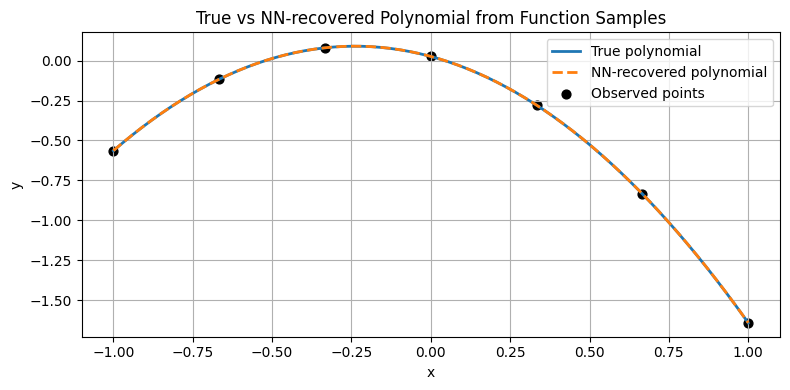

In [4]:
# test NN's coefficient recovery
def test_NN(model, V_sample, n_test=500, coef_scale=1.0, random_state=1776):
    """
    Test NN on unseen random polynomials.
    For each test polynomial:
        1) Draw beta_full.
        2) Compute y_sample = V_sample @ beta_full.
        3) Predict beta_hat = model(y_sample).
        4) Measure errors on coefficients and on function values.
    Args:
    -----
        model (tf.keras.Model): Trained function->coeff NN.
        V_sample (np.ndarray) : Vandermonde at sample points
        n_test (int)          : Number of test polynomials.
        coef_scale (float)    : Std dev of coefficients.
        random_state (int)    : RNG seed.
    Returns:
    --------
        mse_coef (float) : MSE of coefficients.
        mse_func (float) : MSE of function values at x_sample
                           between true polynomial and one from beta_hat.
    """
    # dims
    n_sample, D_plus_1 = V_sample.shape

    # rng
    rng = np.random.default_rng(random_state)

    # accumulators
    mse_coef_list = []
    mse_func_list = []


    # loop through test polynomials
    for i in range(n_test):

        # construct true polynomial, capture degree and coeff. vector
        d_i, beta_true = sample_random_polynomial(degree_max=D_plus_1 - 1,
                                                  coef_scale=coef_scale,
                                                  random_state=rng.integers(0, 1_000_000))

        # function values at sample points
        y_sample = V_sample @ beta_true

        # NN prediction of coefficients
        beta_hat = poly_nn.predict(y_sample.reshape(1, -1), verbose=0).ravel()

        # compute coefficient mse
        mse_coef_i = np.mean((beta_true - beta_hat)**2)
        mse_coef_list.append(mse_coef_i)

        # compare functions on sample grid
        y_true = y_sample
        y_hat  = V_sample @ beta_hat

        # compute function mse
        mse_func_i = np.mean((y_true - y_hat)**2)
        mse_func_list.append(mse_func_i)

    # compute mse across test polynomials
    mse_coef = float(np.mean(mse_coef_list))
    mse_func = float(np.mean(mse_func_list))

    # return MSE tuple
    return mse_coef, mse_func


# test NN OOS, check results
mse_coef, mse_func = test_NN(model=poly_nn, V_sample=V_sample, n_test=500,
                             coef_scale=1.0, random_state=1776)
print("\n=== OOS Test Performance ===")
print("Coefficient MSE:", mse_coef)
print("Function MSE   :", mse_func,"\n\n")

# sample one polynomial for plotting
_, beta_plot = sample_random_polynomial(degree_max=degree_max, coef_scale=1.0,
                                        random_state=2025)

# true samples
y_sample_plot = V_sample @ beta_plot

# NN estimated coeffs
beta_hat_plot = poly_nn.predict(y_sample_plot.reshape(1, -1), verbose=0).ravel()

# reconstruct functions on a dense grid for visualization
x_dense = np.linspace(-1.0, 1.0, 200)
V_dense = build_vandermonde(x_dense, degree_max)
y_true_dense = V_dense @ beta_plot
y_hat_dense  = V_dense @ beta_hat_plot


# plot functions
plt.figure(figsize=(8, 4))

# true and recovered polynomial
plt.plot(x_dense, y_true_dense, label="True polynomial", linewidth=2)
plt.plot(x_dense, y_hat_dense, "--", label="NN-recovered polynomial", linewidth=2)

# sample points
plt.scatter(x_sample, y_sample_plot, color="black", s=40, label="Observed points")

# label, title, legend, display
plt.xlabel("x")
plt.ylabel("y")
plt.title("True vs NN-recovered Polynomial from Function Samples")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

Test coefficient MSE is on the order of $10^{-7}$ and function MSE on the sample grid on the order of $10^{-8}$, indicating essentially perfect recovery up to numerical precision. The plot shows a true polynomial and NN-recovered polynomial lying on top of each other while exactly matching the observed sample points.

## Comparison of Internal Basis to the Monomial Basis

The near zero training loss and test error beg the question of what is the network's internal representation of the vector space. Is the network actually learning a polynomial basis? I compare the internal basis to the monomial basis to answer that question.

The network is trained to learn the inverse map $T: \mathbb{R}^{m} \to \mathbb{R}^{D+1}, \text{ }T(y) = \beta$, which is a linear operator. The network is purely linear, and collapses to

$$
\hat{\beta} = W_{2}W_{1}y + W_{2}b_{1} + b_{2}
$$

Ignoring the bias terms, the map is

$$
\hat{\beta} = My, \quad M = W_{2}W_{1}
$$

but the true inverse map is $\beta = (V^{T}V)^{-1}V^{T}y$. Thus training forces

$$
W_{2}W_{1} \approx (V^{\top}V)^{-1}V^{\top}
$$

Because output $\hat{\beta}$ lies in $\mathbb{R}^{D+1}$ and is identified with polynomials up to degree $D$, the columns of $W_{2} \in \mathbb{R}^{(D+1) \times H}$ naturally define basis polynomials. Writing the $j$-th column of $W_{2}$ as

$$
\gamma^{(j)} =
\begin{bmatrix}
\gamma^{(j)}_0 \\
\gamma^{(j)}_1 \\
\vdots \\
\gamma^{(j)}_D
\end{bmatrix}
\in \mathbb{R}^{D+1},
$$

I associate to it the polynomial

$$
b_j(x) = \sum_{k=0}^{D} \gamma^{(j)}_k x^k.
$$

The network’s second layer defines $H$ 'basis polynomials' $\{b_1,\dots,b_H\}$, and the hidden activations $h \in \mathbb{R}^H$ provide coordinates in this learned basis. I substitute $h = W_{1}y + b_{1}$ into the output layer and expand, rewriting the network’s prediction as

$$
\hat{f}(x)
= \sum_{k=0}^{D} \hat{\beta}_k x^k
= \sum_{j=1}^{H} h_j \, b_j(x),
$$

so the network represents the output polynomial as a linear combination of the internally learned basis functions $b_j(x)$.

To compare this internal basis to the monomial basis $\{1,x,\dots,x^D\}$, I evaluate both sets of functions on a dense grid $\{x_i\}_{i=1}^{n}$. Let $V_{\text{dense}} \in \mathbb{R}^{{n} \times (D+1)}$ be the Vandermonde matrix on this grid, whose $k$-th column is the monomial $x^k$ evaluated at all points, and let $B_{\text{dense}} \in \mathbb{R}^{{n} \times H}$ be the matrix whose $j$-th column is $b_j(x)$ evaluated on the same grid. I then solve the least squares problem

$$
W^\ast
= \underset{W \,\in\, \mathbb{R}^{H \times (D+1)}}{\arg\min}
\;\;
\|\, V_{\text{dense}} - B_{\text{dense}} W \,\|_{F}^{2},
$$
where $\|\cdot\|_{F}$ is the Frobenius norm. The fitted matrix $W^\ast$ provides the best linear reconstruction of each monomial column from the learned basis. For each monomial $x^k$, I compute $R^{2}_{k}$.


=== Monomial Reconstruction R^2 using NN-learned Basis ===


degree,0,1,2,3,4,5
R2_monomial,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


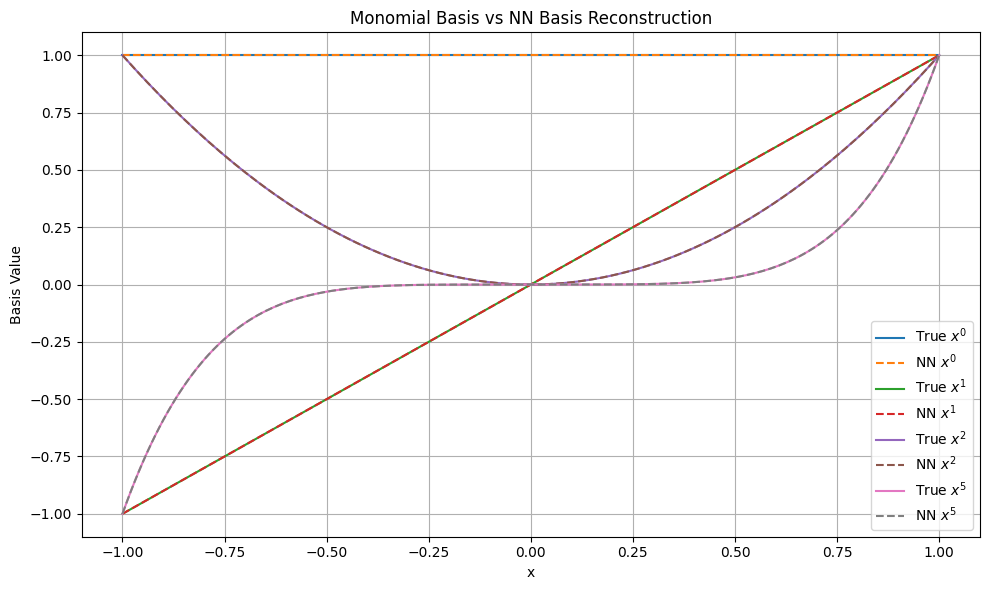

In [5]:
# extract NN's basis
def extract_learned_basis(model, degree_max, x_min=-1.0, x_max=1.0, n_grid=200):
    """
    Extract learned basis functions in function space from the NN.
    Args:
    -----
        model (tf.keras.Model): Trained function->coeff NN.
        degree_max (int)      : Maximum polynomial degree D.
        x_min (float)         : Left endpoint of visualization grid.
        x_max (float)         : Right endpoint of visualization grid.
        n_grid (int)          : Number of grid points.

    Returns:
    --------
        x_dense (np.ndarray)  : Shape (n_grid,), grid for x.
        V_dense (np.ndarray)  : Shape (n_grid, D+1), monomial Vandermonde.
        B_dense (np.ndarray)  : Shape (n_grid, n_hidden), learned basis functions.

    Model structure:
    ----------------
        0: Dense(n_hidden)  with weights W1 (n_sample x n_hidden)
        1: Dense(D+1)       with weights W2 (n_hidden x (D+1))

    For a hidden basis vector e_j (dimension n_hidden), the output coefficients
    are:
        beta^(j) = e_j^T W2 = row_j(W2),

    which define a polynomial

        b_j(x) = sum_{k=0}^D beta_k^(j) x^k.

    Constrcut these basis functions on a dense grid by:

        B_dense[:, j] = V_dense @ beta^(j),

    where V_dense is the Vandermonde on that grid.
    """

    # build dense x-grid
    x_dense = np.linspace(x_min, x_max, n_grid)

    # Vandermonde on dense grid
    V_dense = build_vandermonde(x_dense, degree_max)

    # extract weights from NN
    W1, b1 = model.layers[0].get_weights()
    W2, b2 = model.layers[1].get_weights()

    # coefficient vectors for learned basis functions
    B_coeff = W2.T

    # evaluate learned basis functions on dense grid
    B_dense = V_dense @ B_coeff

    # return tuple
    return x_dense, V_dense, B_dense


def regress_V_on_B(V, B):
    """
    Regress the monomial basis V onto the learned basis B.
    Args:
    -----
        V (np.ndarray): True monomial basis on grid, shape (n_grid, D+1).
        B (np.ndarray): Learned basis functions, shape (n_grid, n_hidden).
    Returns:
    --------
        W_hat (np.ndarray)      : Coefficient matrix, shape (n_hidden, D+1).
        V_hat (np.ndarray)      : Reconstruction of V from B, shape (n_grid, D+1).
        r2_monomial (np.ndarray): R^2 for each monomial column, shape (D+1,).
    Solve V ≈ B W for W using LS and compute R^2 per monomial column.
    """

    # check dimensions
    n_v, D_plus_1 = V.shape
    n_b, n_hidden = B.shape
    if n_v != n_b:
        raise ValueError("V and B must have same number of rows (grid points).")

    # least squares: B W ≈ V
    W_hat, residuals, rank, s = np.linalg.lstsq(B, V, rcond=None)

    # reconstructed monomial basis
    V_hat = B @ W_hat

    # compute R^2 per monomial
    r2_monomial = np.zeros(D_plus_1)

    # loop through monomials
    for j in range(D_plus_1):

        # capture columns of V, V_hat
        v_true = V[:, j]
        v_hat  = V_hat[:, j]

        # compute RSS, TSS
        ss_res = np.sum((v_true - v_hat)**2)
        ss_tot = np.sum((v_true - v_true.mean())**2)

        # compute R2, update array
        r2_monomial[j] = 1.0 - ss_res/ss_tot if ss_tot > 0 else 1.0

    # return tuple
    return W_hat, V_hat, r2_monomial


# extract learned basis functions in function space
x_dense_basis, V_dense_basis, B_dense = extract_learned_basis(model=poly_nn,
                                                              degree_max=degree_max,
                                                              x_min=-1.0,
                                                              x_max=1.0,
                                                              n_grid=200)

# regress monomial basis onto learned basis
W_hat_basis, V_hat_basis, r2_monomial = regress_V_on_B(V=V_dense_basis,
                                                       B=B_dense)

# order R^2 by degree
r2_basis_df = pd.DataFrame({"degree": np.arange(degree_max+1),
                            "R2_monomial": r2_monomial}).T
r2_basis_df.columns  = r2_basis_df.iloc[0].astype(int)
r2_basis_df = r2_basis_df.iloc[1:]


print("\n=== Monomial Reconstruction R^2 using NN-learned Basis ===")
display(r2_basis_df)



# plot comparison
plt.figure(figsize=(10, 6))

# choose degress to plot
degrees_to_plot = [0, 1, 2, degree_max]

# loop through degrees
for d in degrees_to_plot:

    # true monomial x^d on dense grid
    v_true = V_dense_basis[:, d]

    # reconstruction from learned basis
    v_hat = V_hat_basis[:, d]

    # plot true vs reconstructed
    plt.plot(x_dense_basis, v_true, label=fr"True $x^{d}$")
    plt.plot(x_dense_basis, v_hat, "--", label=fr"NN $x^{d}$")

# label, title, grid, plot
plt.xlabel("x")
plt.ylabel("Basis Value")
plt.title("Monomial Basis vs NN Basis Reconstruction")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()


Empirically, I obtain $R^2 = 1.0000$ for every $k = 0,\dots,D$, meaning each monomial can be reconstructed exactly (up to numerical precision) as a linear combination of the learned basis polynomials $\{b_j\}$. The internal representation spans exactly the same vector space as the monomial basis. The plots confirm that the reconstructed monomials lie on top of the true $x^k$ curves. The network has internalized the linear structure of the polynomial vector space rather than merely memorizing sample-label pairs.


## Adversarial Testing

I perform an adversarial test by evaluating the network on a polynomial with degree larger than training maximum $D$ (e.g., $d_{\text{test}} = 15$ while $D = 5$). The network by construction can only output a degree-$D$ coefficient vector, and thus defines a degree-$D$ approximation. I compute MSE between the true function and approximation on a dense grid, then repeat the exercise for a range of degrees $> D$ and multiple drawn coefficient vectors, generating empirical distributions of MSE per degree tested.


=== Adversarial MSE Distribution by Degree ===


,degree,mean,std,min,max
0,6,0.0017,0.0007,0.0000,0.0073
1,7,0.0007,0.0011,0.0003,0.0080
2,8,0.0065,0.0034,0.0002,0.0316
3,9,0.0039,0.0066,0.0002,0.0546
4,10,0.0152,0.0145,0.0001,0.1407
5,11,0.0086,0.0159,0.0003,0.1674
6,12,0.0254,0.0341,0.0006,0.2904
7,13,0.0216,0.0339,0.0010,0.2045
8,14,0.0373,0.0453,0.0007,0.4209
9,15,0.0294,0.0406,0.0006,0.2911


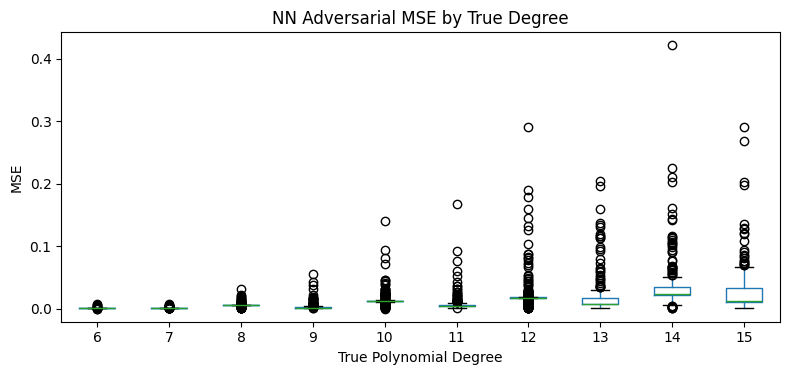

In [6]:
# distribution of adversarial test MSE
def adversarial_mse_dist(model, degree_max, x_sample, x_dense,
                         degrees_test=range(6, 16), n_test_per_degree=200,
                         coef_scale=1.0, random_state=1776):
    """
    Compute MSE distributions for NN approximation of high-degree polynomials.
    Args:
    -----
        model (tf.keras.Model) : Trained function->coeff NN.
        degree_max (int)       : Training maximum degree D.
        x_sample (np.ndarray)  : Sample grid, shape (m,).
        x_dense (np.ndarray)   : Dense grid for evaluation, shape (n_dense,).
        degrees_test (iterable): Degrees d_test > D to test, e.g. range(6,16).
        n_test_per_degree (int): Number of random polynomials per degree.
        coef_scale (float)     : Std dev of coefficients.
        random_state (int)     : rng seed.
    Returns:
    --------
        results_df (pd.DataFrame): Columns ['degree', 'mse'].
    For each degree d_test in degrees_test:
      1) Build Vandermonde matrices V_sample_big, V_dense_big for degree d_test.
      2) For many random polynomials of degree up to d_test:
          a) Draw coefficient vector beta_big (enforce nonzero top coeff).
          b) Compute y_sample_big at x_sample.
          c) Compute y_dense_big on x_dense (true curve).
          d) Use NN to get degree_max coefficients beta_hat_small.
          e) Build degree_max Vandermonde on x_dense and compute y_dense_small.
          f) Store MSE = mean (y_dense_big - y_dense_small)^2.
    """

    # rng
    rng = np.random.default_rng(random_state)

    # degree_max Vandermonde on dense grid (for NN's output space)
    V_dense_small = build_vandermonde(x_dense, degree_max)

    # capture all results
    records = []

    # loop over adversarial degrees
    for d_test in degrees_test:

        # Vandermonde for high degree on sample and dense grids
        V_sample_big = build_vandermonde(x_sample, d_test)
        V_dense_big  = build_vandermonde(x_dense, d_test)

        # loop over random polynomials for this degree
        for _ in range(n_test_per_degree):

            # draw random polynomial up to degree d_test
            _, beta_big = sample_random_polynomial(degree_max=d_test,
                                                   coef_scale=coef_scale,
                                                   random_state=rng.integers(0, 1_000_000))

            # enforce nonzero top-degree coefficient
            if np.abs(beta_big[d_test]) < 1e-3:
                beta_big[d_test] = 1.0

            # function values for high-degree polynomial
            y_sample_big = V_sample_big @ beta_big
            y_dense_big  = V_dense_big  @ beta_big

            # NN prediction: degree_max coefficients
            beta_hat_small = model.predict(y_sample_big.reshape(1, -1),
                                           verbose=0).ravel()

            # NN degree_max approximation on dense grid
            y_dense_small = V_dense_small @ beta_hat_small

            # MSE between true high-degree curve and NN's low-degree approx
            mse_i = np.mean((y_dense_big - y_dense_small)**2)

            # store result
            records.append({"degree": d_test,"mse": mse_i})

    # convert to DataFrame and return
    results_df = pd.DataFrame(records)
    return results_df


# run adversarial experiment over degrees > D
degrees_test = range(degree_max + 1, 16)

# MC samples
n_test_per_degree = 200

# generate distribution of MSE by degree
adversarial_results = adversarial_mse_dist(model=poly_nn, degree_max=degree_max,
                                           x_sample=x_sample, x_dense=x_dense,
                                           degrees_test=degrees_test,
                                           n_test_per_degree=n_test_per_degree,
                                           coef_scale=1.0, random_state=2025)

# summary statistics by degree
summary_stats = adversarial_results.groupby("degree")["mse"]
summary_stats = summary_stats.agg(["mean", "std", "min", "max"]).reset_index()

# check results
print("\n=== Adversarial MSE Distribution by Degree ===")
display(summary_stats)


# boxplot of MSE distribution by true degree
adversarial_results.boxplot(column="mse", by="degree", grid=True,
                            figsize=(8,4))
plt.suptitle("")
plt.title("NN Adversarial MSE by True Degree")
plt.xlabel("True Polynomial Degree")
plt.ylabel("MSE")
plt.grid()
plt.tight_layout()
plt.show()

MSE distributions widen with degree, although the shift in mean isn't pronounced until higher degrees. Naturally, a degree 5 approximation of a $d > 5$ degree polynomial degrades as $d$ increases.


=== Adversarial Test Example ===
	 degree_test = 15, training D = 5
	 Test D = 15, NN D = 5, MSE = 0.10386132474405267


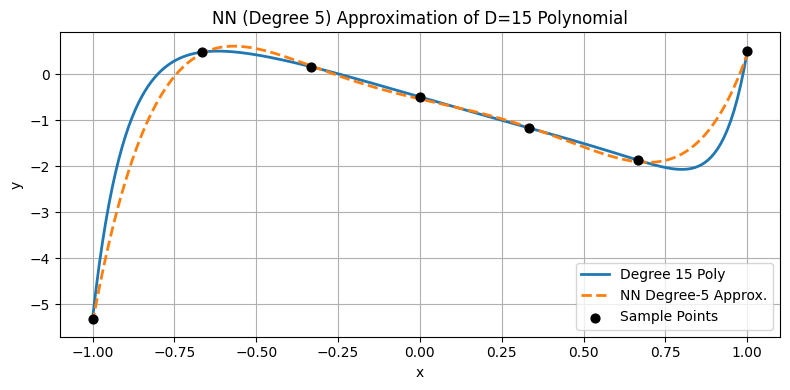

In [7]:
# plot example D=15
degree_test = 15

# Vandermonde for degree_test on sample and dense grids
V_sample_big = build_vandermonde(x_sample, degree_test)
V_dense_big  = build_vandermonde(x_dense, degree_test)

# draw a single random degree_test polynomial
_, beta_big = sample_random_polynomial(degree_max=degree_test,
                                       coef_scale=1.0,
                                       random_state=999)

# enforce nonzero top coefficient
if np.abs(beta_big[degree_test]) < 1e-3:
    beta_big[degree_test] = 1.0

# true function values
y_sample_big = V_sample_big @ beta_big
y_dense_big  = V_dense_big  @ beta_big

# NN approximation (degree_max)
beta_hat_small = poly_nn.predict(y_sample_big.reshape(1, -1),verbose=0).ravel()
V_dense_small = build_vandermonde(x_dense, degree_max)
y_dense_small = V_dense_small @ beta_hat_small

# MSE on dense grid
mse_adversarial = np.mean((y_dense_big - y_dense_small)**2)

print("\n=== Adversarial Test Example ===")
print(f"\t degree_test = {degree_test}, training D = {degree_max}")
print(f"\t Test D = {degree_test}, NN D = {degree_max}, MSE = {mse_adversarial}")

# plot true vs NN approximation
plt.figure(figsize=(8, 4))
plt.plot(x_dense, y_dense_big, label=f"Degree {degree_test} Poly",linewidth=2)
plt.plot(x_dense, y_dense_small, "--", label=f"NN Degree-{degree_max} Approx.",
         linewidth=2)
plt.scatter(x_sample, y_sample_big, color="black", s=40, zorder=5, label="Sample Points")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"NN (Degree {degree_max}) Approximation of D={degree_test} Polynomial")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

The NN approximation interpolates the sample points well but deviates from the true degree 15 curve between those points. This is to be expected because the model learns a finite-dimensional polynomial subspace of degree $\le D$. The model generalizes perfectly within that subspace, but when presented with a higher-degree function effectively returns the best degree-$D$ approximation that matches the observed points but deviates between them, consistent with a projection onto a lower-dimensional subspace.

## Results

The experiment shows that a simple linear neural network can learn the exact inverse of the Vandermonde-based map for polynomials of degree $\le D$ without any explicit knowledge of the monomial basis or the analytic inverse, using only function sample values and coefficient vectors. The network achieves essentially zero error in recovering coefficients and reconstructing polynomials on held-out examples, and its internal basis functions span the same function space as the monomials. This shows that rather than memorizing sample-label pairs, the network internalized the linear operator structure of the interpolation problem and has learned a basis for the vector space. When presented with polynomials whose degree exceeds the training maximum, the network cannot represent the true function but instead produces the degree-$D$ polynomial that best matches the observed samples, behaving like a projection onto the learned subspace of degree-$D$ polynomials.